# Gold Price Analysis 2015-2025
### Exploring 10 years of Gold market trends, returns, volatility, and correlation with US Dollar

In [47]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

In [48]:
gold = yf. download("GC=F",start="2015-01-01", end="2025-12-31")
print(gold.head())

[*********************100%***********************]  1 of 1 completed

Price             Close         High          Low         Open Volume
Ticker             GC=F         GC=F         GC=F         GC=F   GC=F
Date                                                                 
2015-01-02  1186.000000  1194.500000  1169.500000  1184.000000    138
2015-01-05  1203.900024  1206.900024  1180.099976  1180.300049    470
2015-01-06  1219.300049  1220.000000  1203.500000  1203.500000     97
2015-01-07  1210.599976  1219.199951  1210.599976  1219.199951     29
2015-01-08  1208.400024  1215.699951  1206.300049  1207.000000     92


In [49]:
print(gold.shape)

(2764, 5)


In [50]:
print(gold.info())

<class 'pandas.DataFrame'>
DatetimeIndex: 2764 entries, 2015-01-02 to 2025-12-30
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Close, GC=F)   2764 non-null   float64
 1   (High, GC=F)    2764 non-null   float64
 2   (Low, GC=F)     2764 non-null   float64
 3   (Open, GC=F)    2764 non-null   float64
 4   (Volume, GC=F)  2764 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 129.6 KB
None


In [51]:
print(gold.describe())

Price         Close         High          Low         Open         Volume
Ticker         GC=F         GC=F         GC=F         GC=F           GC=F
count   2764.000000  2764.000000  2764.000000  2764.000000    2764.000000
mean    1770.558356  1779.264400  1761.412518  1770.045767    5148.056802
std      664.177811   668.740681   658.536729   663.081221   28249.824278
min     1050.800049  1062.000000  1046.199951  1053.699951       0.000000
25%     1272.549988  1276.475006  1266.975006  1272.174957      51.000000
50%     1704.900024  1714.850037  1694.599976  1704.349976     202.000000
75%     1937.100006  1946.749969  1928.299957  1937.024994     626.250000
max     4529.100098  4556.299805  4502.000000  4512.000000  386334.000000


In [52]:
print(gold.isnull().sum())
print(gold.duplicated().sum())

Price   Ticker
Close   GC=F      0
High    GC=F      0
Low     GC=F      0
Open    GC=F      0
Volume  GC=F      0
dtype: int64
0


## Data Cleaning Check
Data is clean — no null values, no duplicates found. No cleaning required.

## 1. Gold Price Trend - Daily (2015-2025)

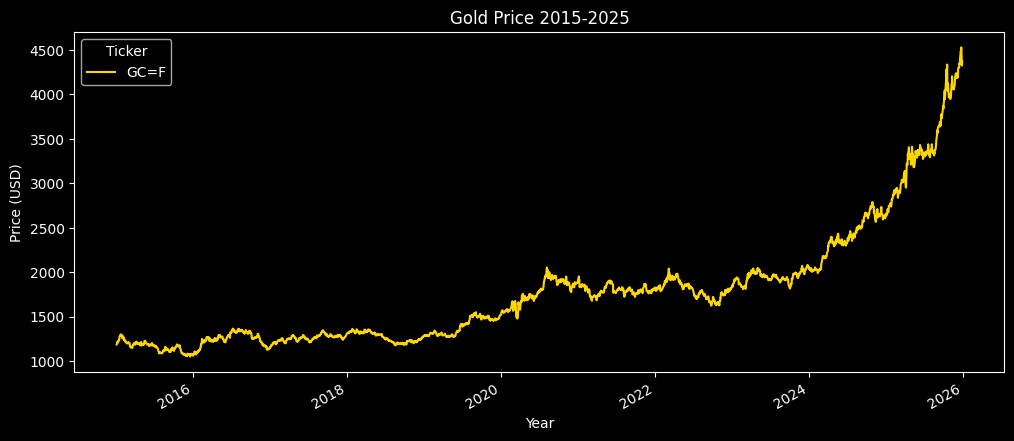

In [53]:
plt.style.use('dark_background')
gold["Close"].plot(figsize=(12,5), title="Gold Price 2015-2025", color="gold")
plt.xlabel("Year")
plt.ylabel("Price (USD)")
plt.show()



Gold rose from ~$1050 to ~$4500 over 10 years — nearly 4x growth.
High volatility visible during COVID-19 (2020) and Russia-Ukraine war (2022-2024).

## 2. Gold Price Trend - Monthly Average (2015-2025)

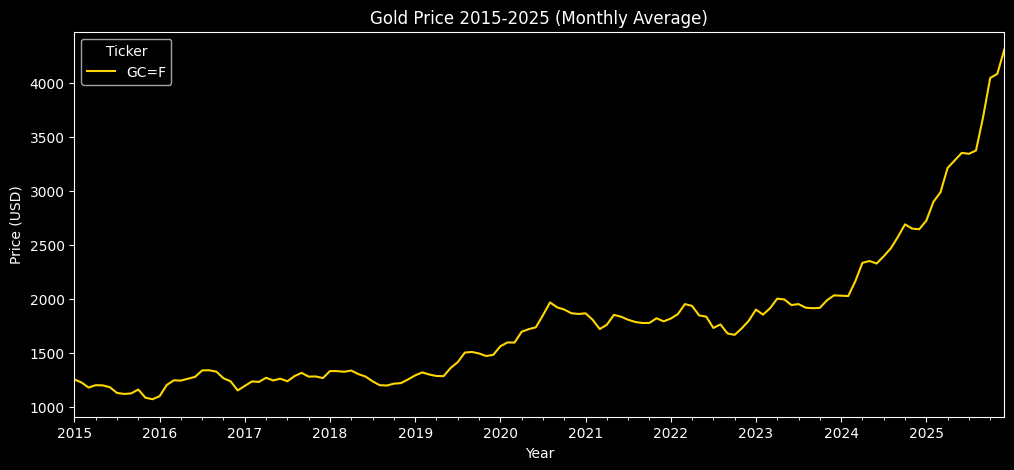

In [54]:
gold_monthly = gold["Close"].resample("ME").mean()
gold_monthly.plot(figsize=(12,5), title="Gold Price 2015-2025 (Monthly Average)", color="gold")
plt.style.use('dark_background')
plt.xlabel("Year")
plt.ylabel("Price (USD)")
plt.show()


Monthly averages smooth out daily noise, clearly showing gold's long-term upward trajectory.
Steady growth post-2018, with sharp acceleration after 2022.

In [55]:
gold_yearly = gold[("Close", "GC=F")].resample("YE").last()
gold_yearly_return = gold_yearly.pct_change() * 100
print(gold_yearly_return)

Date
2015-12-31          NaN
2016-12-31     8.459865
2017-12-31    13.591309
2018-12-31    -2.143459
2019-12-31    18.868806
2020-12-31    24.587034
2021-12-31    -3.465215
2022-12-31    -0.426815
2023-12-31    13.337361
2024-12-31    27.482548
2025-12-31    66.214064
Freq: YE-DEC, Name: (Close, GC=F), dtype: float64


## 3. Yearly Returns Analysis (2015-2025)

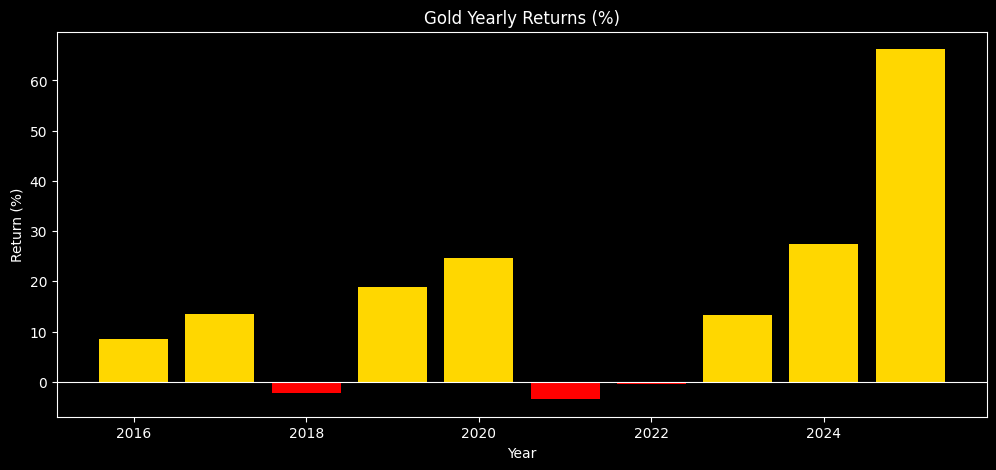

In [56]:
colors = ["gold" if x > 0 else "red" for x in gold_yearly_return.dropna()]

plt.style.use("dark_background")
plt.figure(figsize=(12,5))
plt.bar(gold_yearly_return.dropna().index.year, gold_yearly_return.dropna().values, color=colors)
plt.title("Gold Yearly Returns (%)")
plt.xlabel("Year")
plt.ylabel("Return (%)")
plt.axhline(0, color="white", linewidth=0.8)
plt.show()


Gold delivered positive returns in 8 out of 10 years — a strong long-term asset.
Only 2018 and 2021 saw negative returns, driven by strong dollar and post-COVID equity boom respectively.

In [57]:
gold_close = gold[("Close", "GC=F")]
ma50 = gold_close.rolling(window=50).mean()
ma200 = gold_close.rolling(window=200).mean()

print(ma50.tail())
print(ma200.tail())


Date
2025-12-23    4156.127979
2025-12-24    4162.965977
2025-12-26    4170.009980
2025-12-29    4170.907979
2025-12-30    4174.511982
Name: (Close, GC=F), dtype: float64
Date
2025-12-23    3570.669491
2025-12-24    3578.376991
2025-12-26    3586.100991
2025-12-29    3592.753992
2025-12-30    3599.604492
Name: (Close, GC=F), dtype: float64


## 4. Moving Averages - 50 Day & 200 Day

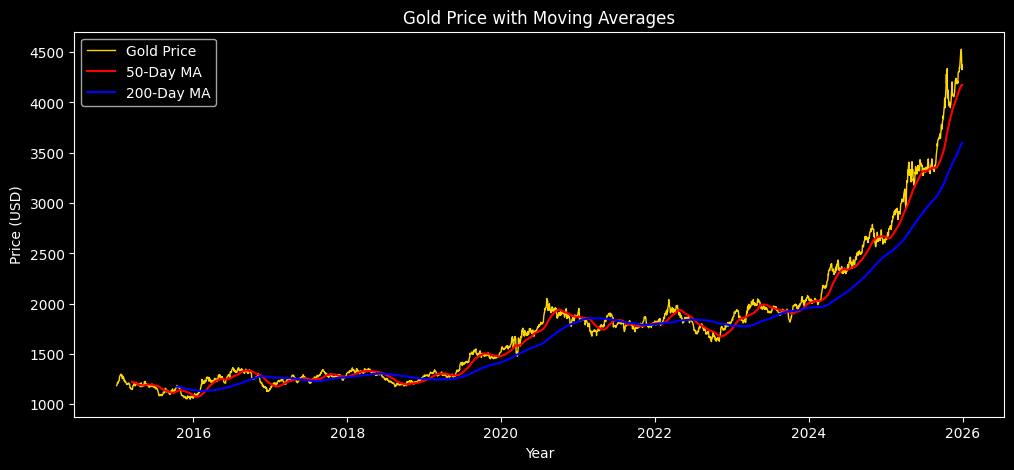

In [58]:


plt.style.use("dark_background")
plt.figure(figsize=(12,5))
plt.plot(gold_close.index, gold_close.values, color="gold", label="Gold Price", linewidth=1)
plt.plot(ma50.index, ma50.values, color="red", label="50-Day MA", linewidth=1.5)
plt.plot(ma200.index, ma200.values, color="blue", label="200-Day MA", linewidth=1.5)
plt.title("Gold Price with Moving Averages")
plt.xlabel("Year")
plt.ylabel("Price (USD)")
plt.legend()
plt.show()


50-day MA crossing above 200-day MA is known as "Golden Cross" — a bullish signal.
Gold showed strong Golden Cross patterns in 2019 and 2023, both followed by significant price rallies.

## 5. Trading Volume Analysis (2015-2025)

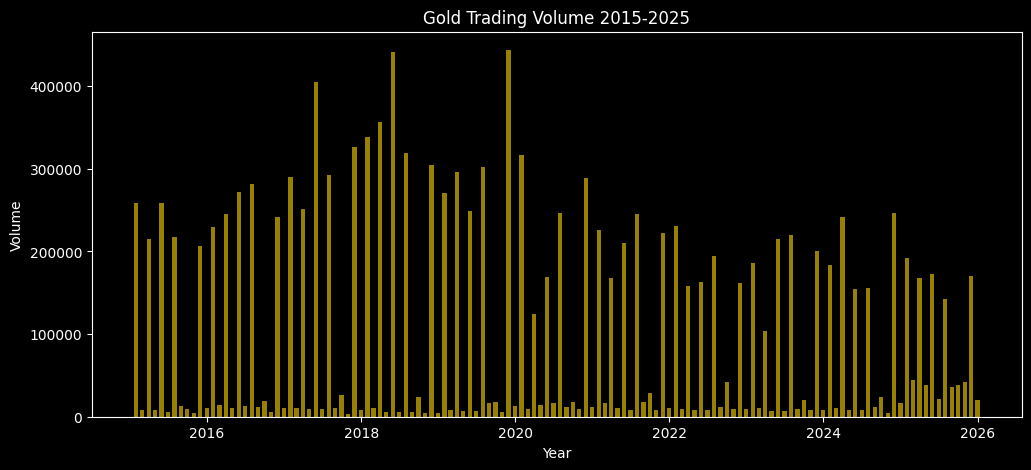

In [59]:

gold_volume_monthly = gold[("Volume", "GC=F")].resample("ME").sum()

plt.style.use("dark_background")
plt.figure(figsize=(12,5))
plt.bar(gold_volume_monthly.index, gold_volume_monthly.values, color="gold", alpha=0.6, width=20)
plt.title("Gold Trading Volume 2015-2025")
plt.xlabel("Year")
plt.ylabel("Volume")
plt.show()


Trading volume spiked significantly during COVID-19 (2020) and Russia-Ukraine war (2022).
High volume during price surges confirms strong market conviction behind gold's rally.

## 6. Daily Returns Distribution

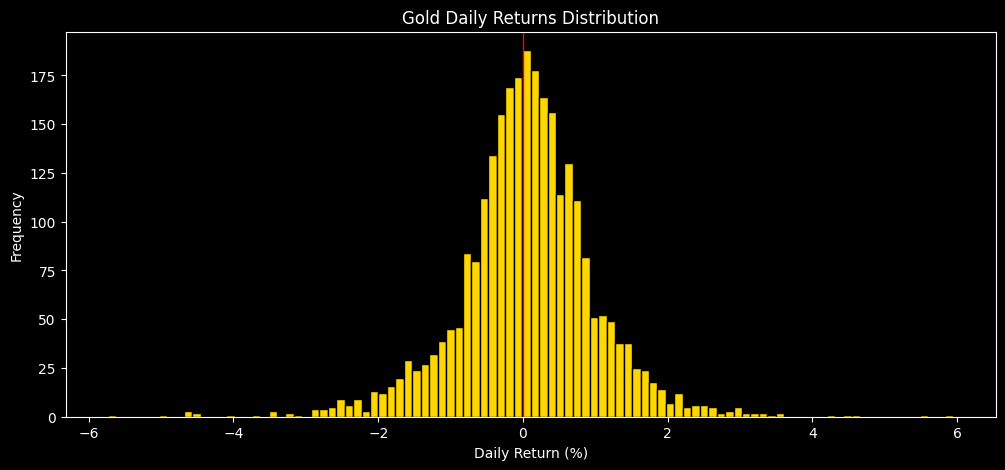

In [60]:
daily_returns = gold[("Close", "GC=F")].pct_change().dropna() * 100

plt.style.use("dark_background")
plt.figure(figsize=(12,5))
plt.hist(daily_returns, bins=100, color="gold", edgecolor="black")
plt.title("Gold Daily Returns Distribution")
plt.xlabel("Daily Return (%)")
plt.ylabel("Frequency")
plt.axvline(0, color="red", linewidth=1)
plt.show()


Gold's daily returns follow a normal distribution — majority of days show less than ±1% movement.
This confirms gold as a low volatility asset, making it a reliable safe-haven investment.

In [61]:
dxy = yf.download("DX-Y.NYB", start="2015-01-01", end="2025-12-31")
print(dxy.head())


[*********************100%***********************]  1 of 1 completed

Price           Close       High        Low       Open   Volume
Ticker       DX-Y.NYB   DX-Y.NYB   DX-Y.NYB   DX-Y.NYB DX-Y.NYB
Date                                                           
2015-01-02  91.080002  91.160004  90.330002  90.360001        0
2015-01-05  91.379997  91.779999  91.129997  91.129997        0
2015-01-06  91.500000  91.809998  91.120003  91.379997        0
2015-01-07  91.889999  92.269997  91.650002  91.750000        0
2015-01-08  92.370003  92.529999  91.940002  91.940002        0


In [62]:
gold_monthly_close = gold[("Close", "GC=F")].resample("ME").mean()
dxy_monthly_close = dxy[("Close", "DX-Y.NYB")].resample("ME").mean()

correlation = gold_monthly_close.corr(dxy_monthly_close)
print("Correlation:", correlation)



Correlation: 0.34617308184473133


## 7. Gold vs US Dollar Index (DXY) Correlation

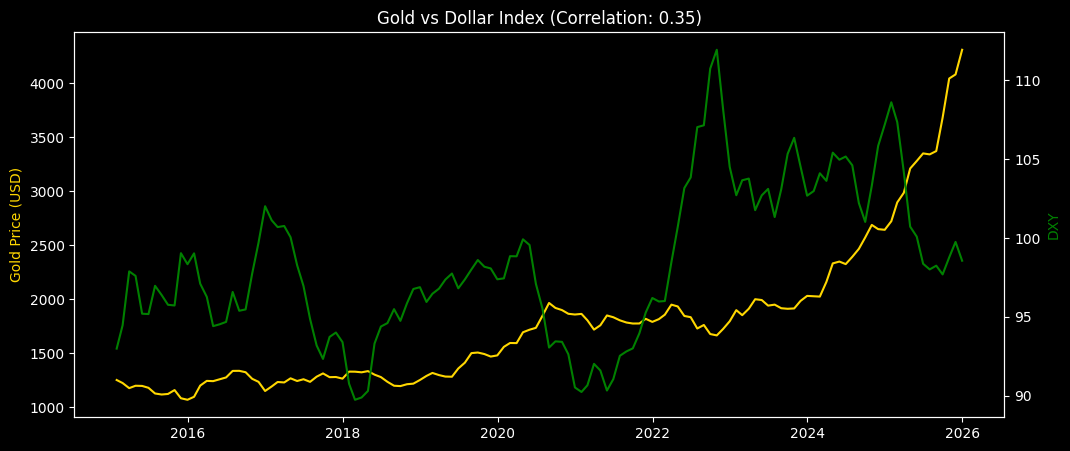

In [63]:

plt.style.use("dark_background")
fig, ax1 = plt.subplots(figsize=(12,5))

ax1.plot(gold_monthly_close.index, gold_monthly_close.values, color="gold", label="Gold Price")
ax1.set_ylabel("Gold Price (USD)", color="gold")

ax2 = ax1.twinx()
ax2.plot(dxy_monthly_close.index, dxy_monthly_close.values, color="green", label="DXY")
ax2.set_ylabel("DXY", color="green")

plt.title(f"Gold vs Dollar Index (Correlation: {correlation:.2f})")
plt.show()

Correlation between Gold and DXY stands at 0.34 — weaker than expected inverse relationship.
Dollar dominated 2015-2022, but Gold ultimately outperformed — driven by inflation fears and geopolitical tensions post-2022.

### Conclusion

# Key Takeaways
- Gold delivered ~4x returns over 10 years — strong long-term asset
- Positive returns in 8 out of 10 years — consistent performer
- Low daily volatility confirms gold as a safe-haven asset
- Gold vs Dollar correlation weakened post-2022 — geopolitical factors now dominate
- Moving Average Golden Cross patterns proved reliable bullish signals
